<a href="https://colab.research.google.com/github/Yonaki97/DataScience/blob/main/TugasPRA_UTS_Feature_Extraction_Agung_Rezalky_10123171.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identitas
- Nama        : Agung Rezalky
- NIM         : 10123171
- Kelas       : IF-4
- Judul Tugas : Feature Extraction pada Citra Tanaman untuk Klasifikasi Jenis Tanaman

# Deskripsi Dataset

- <h1>Sumber Dataset</h1> Menggunakan API untuk memperoleh Dataset/Gambar dengan menggunakan Library Python, yakni: Bing-Image-Downloader.
Gambar tersebut diperoleh dari https://www.bing.com/. cara kerjanya adalah, user input keyword ('Rose') lalu library akan mencarikan gambar sesuai keyword tersebut.
- <h1>Jumlah Data</h1>
1138 Data
- <h1>Jumlah Fitur</h1>
 Ada 5, yaitu:
- 250 (sunflower)
- 202 (Cactus)
- 299 (Rose)
- 195 (Jasmine)
- 192 (Anggrek)
- <h1>Tipe Data</h1> Gambar
- <h1>Tujuan Analisis</h1>
Tujuan analisis pada dataset ini adalah untuk membangun model klasifikasi citra tanaman yang mampu membedakan beberapa jenis tanaman berdasarkan gambar, yaitu Sunflower, Anggrek, Jasmine, Rose, dan Cactus. namun untuk tugas ini, difokuskan terhadap bunga Rose.
Dataset lengkap : https://drive.google.com/drive/u/1/folders/1fluFkN7rNjVAvD8RwAwm0wpqHTEKhI6y

#Import Library

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import normalize
import numpy as np
import gdown

## Penjelasan setiap Library
<h2> Os </h2>
Library bawaan Python untuk:
mengelola file dan folder.
Dipakai untuk: <br>
- membaca isi folder<br>
- membuat folder<br>
- mengecek path<br>
- looping dataset gambar.
<h2> Cv2(Computer Vision)</h2>
Apa itu OpenCV adalah sebuah library(perpustakaan) yang digunakan untuk mengolah gambar dan video. Kata open pada OpenCV dimaksudkan opensource gratis, tidak berbayar, bisa didownload dimana saja. Sementara CV pada kata OpenCV adalah kependekan dari Computer Vision,ini berarti menggunakan komputer yang diambil untuk mengolah image (citra/gambar) yang ditangkap oleh alat perekam seperti kamera atau webcam yang dikonversi dari analog ke digital lalu diolah dalam komputer. Source : " https://idmetafora.com/news/read/1177/Mengenal-OpenCV-Dalam-Python-Pengertian-Sejarah-Dukungan-pada-OS-Fitur-fitur.html "
<h2>matplotlib.pyplot as plt</h2>
Library visualisasi data dari Matplotlib
pyplot digunakan untuk:<br>
- menampilkan grafik<br>
- menampilkan gambar<br>
- histogram<br>
- plotting data.
<h2>skimage.feature import graycomatrix, graycopros</h2>
graycomatrix dan graycoprops merupakan fungsi dari library scikit-image yang digunakan untuk ekstraksi fitur tekstur pada citra digital menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Metode ini bekerja dengan menganalisis hubungan antar nilai intensitas piksel pada citra grayscale untuk memperoleh karakteristik tekstur gambar.

<h2> Gdown</h2>
gdown sering digunakan dalam proyek machine learning, data science, dan image processing karena banyak dataset disimpan di Google Drive. Dengan menggunakan library ini, pengguna dapat mengakses file hanya dengan memasukkan link atau ID file dari Google Drive.

<h2> Import numpy as np</h2>
NumPy adalah paket dasar untuk komputasi ilmiah di Python. Ini adalah pustaka Python yang menyediakan objek array multidimensi, berbagai objek turunan (seperti array bertopeng dan matriks), dan berbagai rutin untuk operasi cepat pada array, termasuk operasi matematika, logika, manipulasi bentuk, pengurutan, pemilihan, I/O, transformasi Fourier diskrit, aljabar linier dasar, operasi statistik dasar, simulasi acak, dan masih banyak lagi.

<h2>from sklearn.preprocessing import normalize</h2>
normalize dari sklearn digunakan untuk mengubah skala vektor sehingga panjangnya (norm) menjadi 1, tanpa mengubah arahnya.

# Load Dataset

In [ ]:
folder_id = "1YHv_mwSEsPVxu3_8niA_2alQYjSLGsia"
gdown.download(id=folder_id, output="dataset/", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1YHv_mwSEsPVxu3_8niA_2alQYjSLGsia
To: /content/dataset/Kelompok_2_Tugas_Rekayasa_Fitur_Data_Gambar_Rose_221.jpg
100%|██████████| 155k/155k [00:00<00:00, 24.8MB/s]


'dataset/Kelompok_2_Tugas_Rekayasa_Fitur_Data_Gambar_Rose_221.jpg'

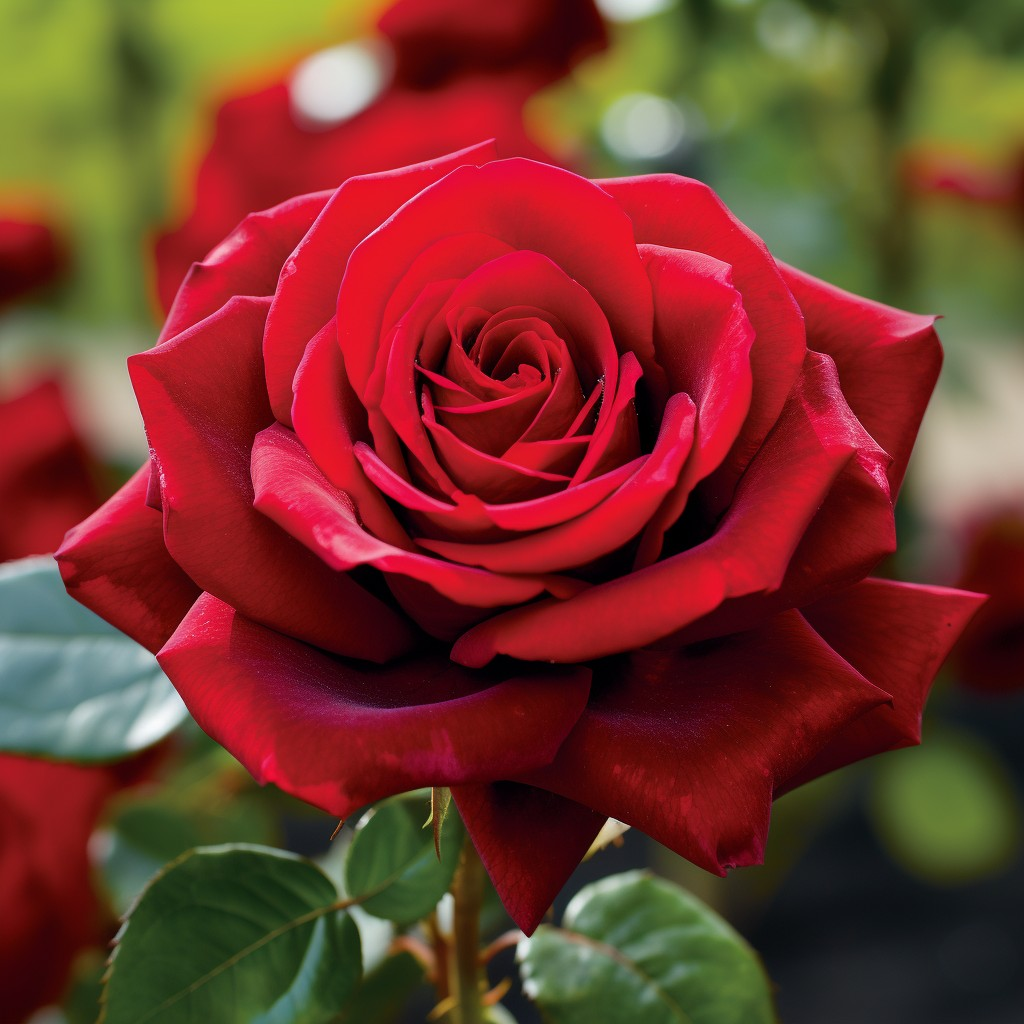

In [ ]:
image =cv2.imread("dataset/Kelompok_2_Tugas_Rekayasa_Fitur_Data_Gambar_Rose_221.jpg")
cv2_imshow(image)

Gambar yang digunakan sebagai contoh analisis adalah bunga Rose

#Pemahaman Data

## Shape

In [ ]:
Shape  = image.shape
Height = image.shape[0]
Width = image.shape[1]
Channel = image.shape[2]

print("Shape : ", Shape)
print("Height : ", Height)
print("Width : ", Width)
print("Channel : ", Channel)

Shape :  (1024, 1024, 3)
Height :  1024
Width :  1024
Channel :  3


<h3>Pentingnya cek shape pada dataset/gambar adalah untuk mengetahui konsistensi dataset, Menentukan Teknik Preprocessing, Menentukan Beban Komputasi, Memahami Struktur Data</h3>

## Info

In [ ]:
Typeimage = image.dtype
Size = image.size

print("Tipe Data : ", Typeimage)
print("Total Pixe; : ", Size)

Tipe Data :  uint8
Total Pixe; :  3145728


<h3>Pentingnya cek Size pada dataset/gambar adalah untuk mengetahui Kompleksitas Dataset, Pengaruh ke Memori dan Training, Membantu Keputusan Resize, Mengetahui Jumlah Informasi Pixel</h3>

## Statistik

In [ ]:
Min = image.min()
Max = image.max()

print("Min : ", Min)
print("Max : ", Max)
print(f"Mean : {image.mean():.2f}")
print(f"Std : {image.std():.2f}")

Min :  0
Max :  255
Mean : 71.29
Std : 61.42


<h3>
Mean Untuk mengetahui:
brightness gambar.<br>
Std Untuk mengetahui:
kontras, variasi tekstur, noise. seberapa besar variasi intensitas pixel.<br>
Min & Max Untuk mengetahui:
rentang intensitas pixel, apakah normalisasi diperlukan.

## Distribusi


 Visualisasi Channel RGB 



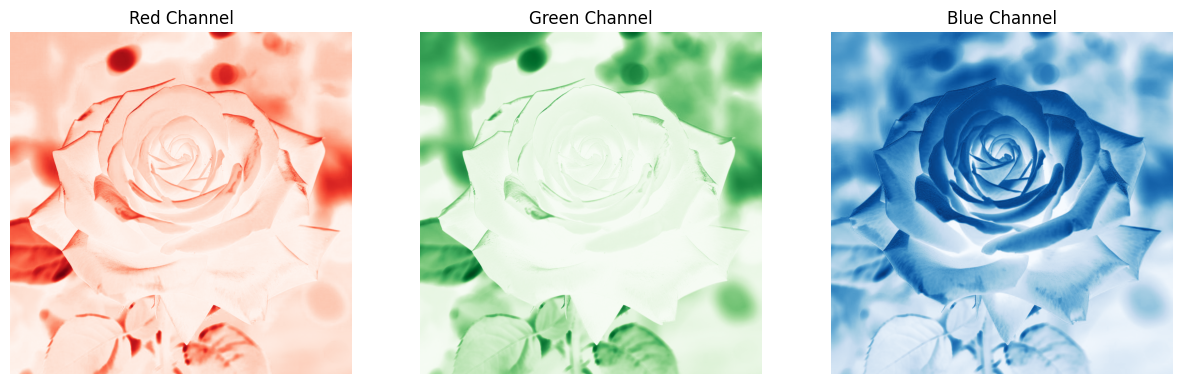


 DISTRIBUSI DATA 



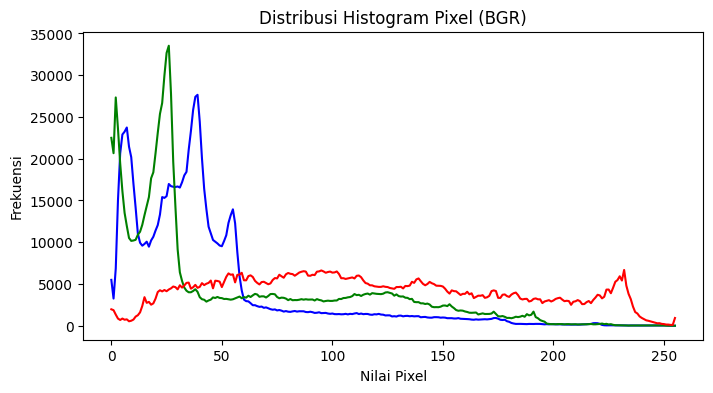

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# Visualisasi Channel RGB
print("\n Visualisasi Channel RGB \n")
ax[0].imshow(image[:,:,0], cmap='Reds')
ax[0].set_title('Red Channel')
ax[0].axis('off')

ax[1].imshow(image[:,:,1], cmap='Greens')
ax[1].set_title('Green Channel')
ax[1].axis('off')

ax[2].imshow(image[:,:,2], cmap='Blues')
ax[2].set_title('Blue Channel')
ax[2].axis('off')

plt.show()
print("\n DISTRIBUSI DATA \n")
colors = ('b', 'g', 'r')
plt.figure(figsize=(8, 4))
for i, col in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
plt.title('Distribusi Histogram Pixel (BGR)')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')
plt.show()

<h3>Distribusi diatas digunakan untuk :

- memvisualisasikan channel RGB,
- menganalisis distribusi warna,
- memahami intensitas pixel,
- mengevaluasi karakteristik citra sebelum preprocessing

# Preprocessing Data

## Resize

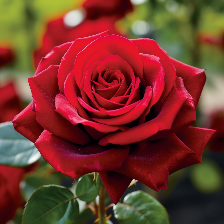

In [ ]:
resize_image = cv2.resize(image, (224, 224))
cv2_imshow(resize_image)

Mengatur size gambar agar semua mempunyai shape yang konsisten ( Width x Height )

- semua gambar punya ukuran konsisten
- mempercepat training

## Grayscale

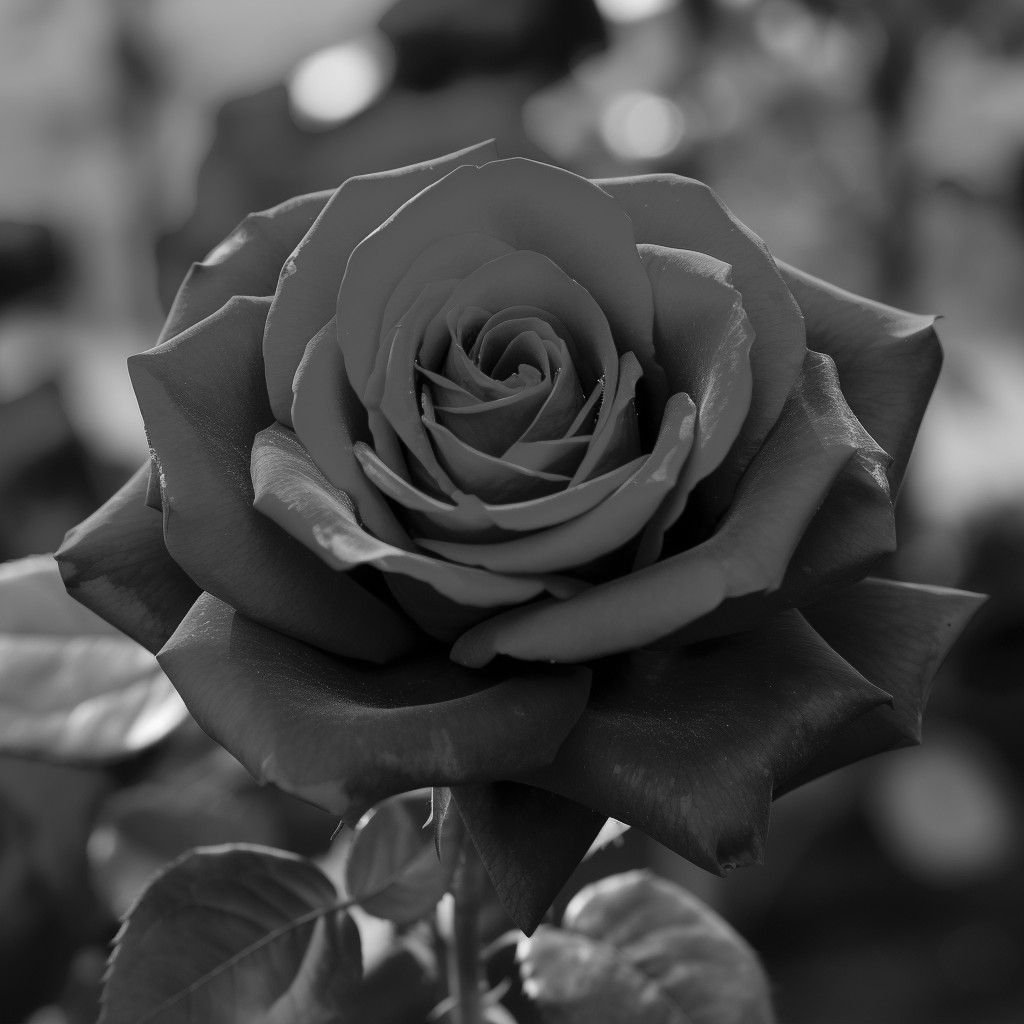

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

Mengubah gambar berwarna menjadi hitam-putih.
- mengurangi kompleksitas data,
- fokus pada bentuk/tekstur,
- mempercepat proses komputasi.

## Normalisasi

In [ ]:
normalized = image / 255.0

<h3>
Normalisasi adalah proses mengubah nilai piksel mentah (0–255) menjadi rentang yang lebih kecil dan seragam agar proses training lebih stabil dan cepat konvergen.<br>
Setiap piksel dalam gambar digital disimpan sebagai integer 8-bit, artinya hanya bisa menyimpan nilai dari 0 sampai 255 (total 256 kemungkinan nilai). Angka 255 adalah nilai maksimum yang mungkin, jadi membagi dengannya akan selalu menghasilkan angka antara 0.0 dan 1.0.

## Noise Reduction

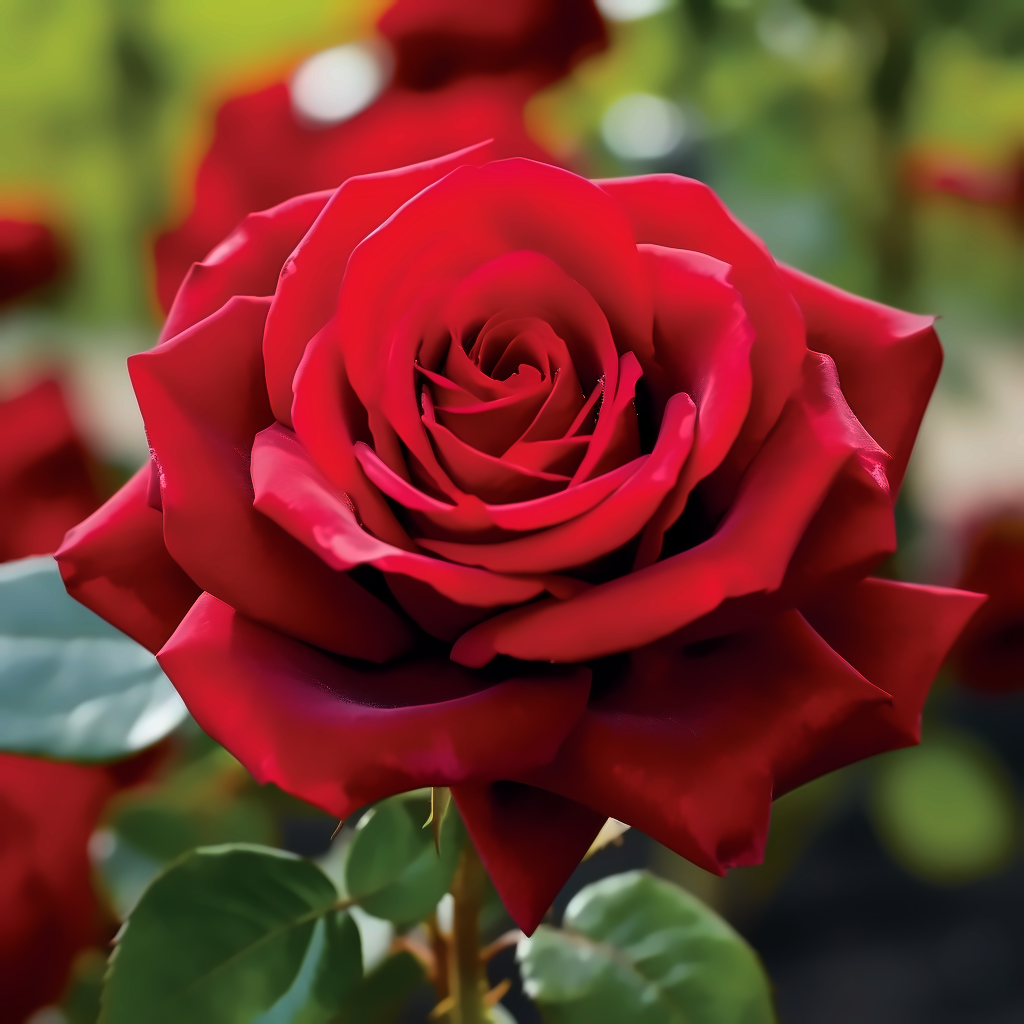

In [ ]:
denoised = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
cv2_imshow(denoised)

<h3>Noise Reduction adalah proses menghilangkan atau mengurangi gangguan (noise) pada gambar yang tidak diinginkan, sebelum gambar diproses lebih lanjut oleh model.
fastNlMeansDenoisingColored adalah implementasi dari Non-Local Means. "Non-local" -> tidak hanya lihat tetangga dekat, tapi cari patch serupa di seluruh searchWindowSize (21×21).

<br><br>
Berikut adalah apa yang terjadi pada code <br>
cv2.fastNlMeansDenoisingColored(image, None, h=3,  hColor=3,  templateWindowSize=7, searchWindowSize=21)

## Blurring/Smoothing

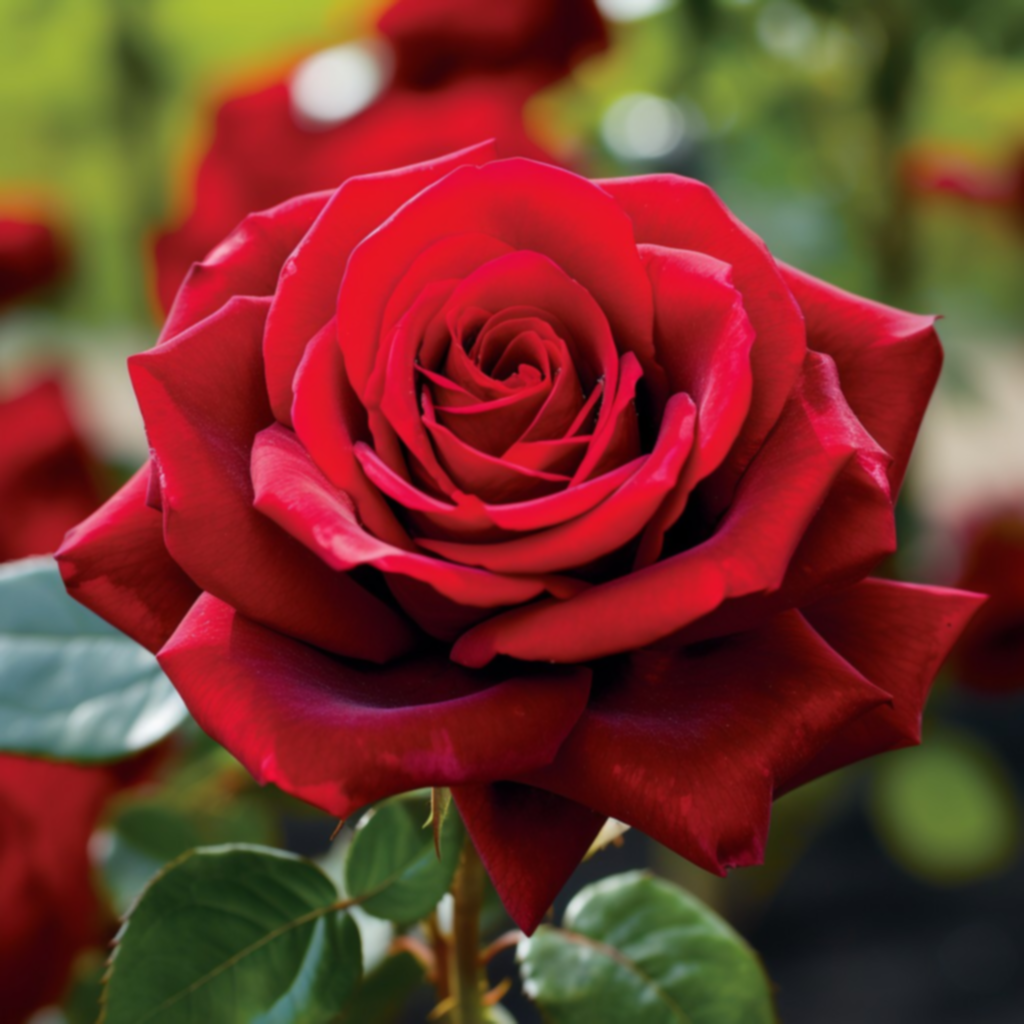

In [ ]:
blurred = cv2.GaussianBlur(image, (5, 5), 0)
cv2_imshow(blurred)

<h3>Gaussian Blur adalah teknik menghaluskan gambar dengan cara merata-rata nilai piksel berdasarkan distribusi Gaussian. piksel di tengah diberi bobot lebih besar, semakin jauh semakin kecil bobotnya.

Kernel Gaussian adalah matriks bobot berbentuk "gunung", piksel di tengah mendapat bobot paling besar, semakin jauh dari tengah bobotnya semakin kecil mengikuti kurva Gaussian. Nilai piksel hasil adalah jumlah perkalian setiap piksel tetangga dengan bobotnya, lalu dibagi total bobot. Hasilnya piksel noise yang nilainya berbeda jauh dari tetangganya akan "ditarik" mendekati nilai rata-rata sekitarnya — noise teredam.

#Rekayasa Fitur ( Feature Extraction )
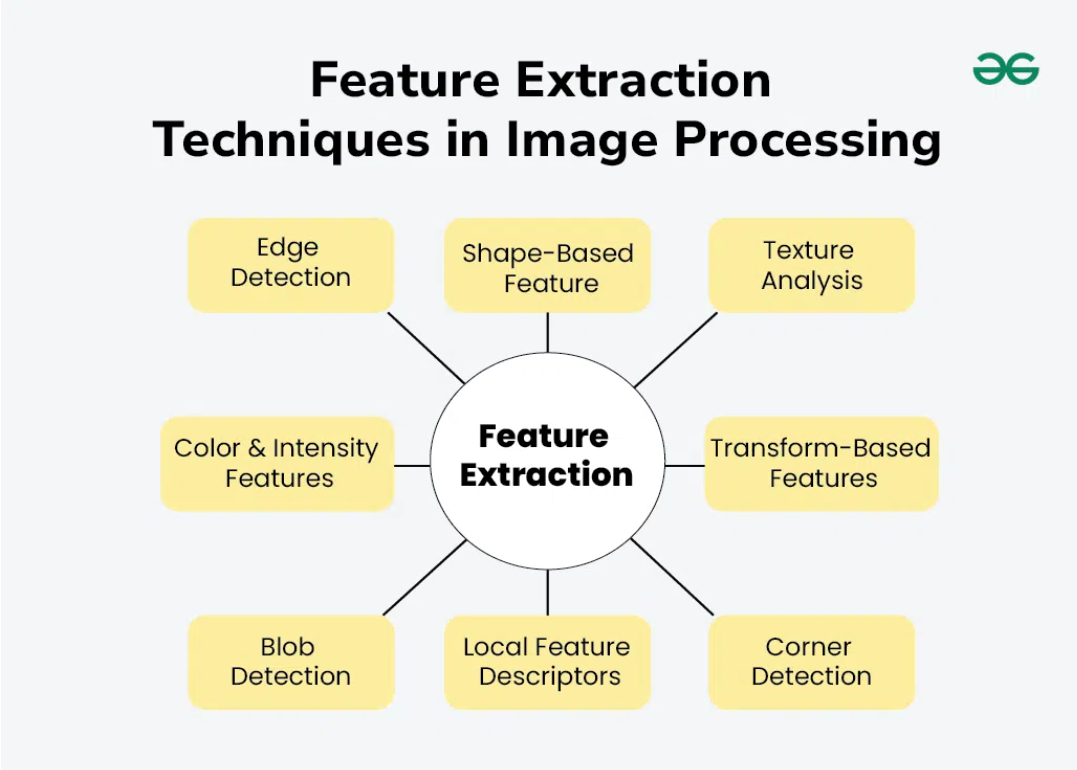

<br>Kenapa Feature Extraction penting?
- Pengurangan Dimensi (Dimensionality Reduction): Gambar umumnya memiliki dimensi yang sangat tinggi sehingga membutuhkan komputasi yang besar. Seleksi fitur dapat digunakan untuk mengurangi jumlah fitur yang dipertimbangkan sambil tetap mempertahankan informasi penting yang dibutuhkan.
- Peningkatan Akurasi (Improved Accuracy): Pemisahan fitur-fitur penting akan meningkatkan kinerja tugas pengolahan citra seperti klasifikasi dan deteksi.
- Peningkatan Performa (Enhanced Performance): Ekstraksi fitur yang efisien memungkinkan sistem menangani aplikasi secara real-time dengan kebutuhan daya komputasi yang lebih terjangkau.
- Pengurangan Noise (Noise Reduction): Dengan berfokus pada aspek-aspek penting, informasi yang tidak relevan dan berulang (sering disebut noise) dapat dihilangkan sehingga menghasilkan model yang lebih stabil dan andal.

## Edge Detection

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 150, 255)

### Canny Edge Detection

Algoritma untuk mendeteksi tepi (batas objek) dengan mencari area di mana nilai piksel **berubah drastis**.

---

### Tahapan Proses

| Tahap | Nama | Fungsi |
|---|---|---|
| 1 | Gaussian Blur | Mengurangi noise sebelum deteksi |
| 2 | Gradient Magnitude & Arah | Mencari perubahan intensitas piksel |
| 3 | Non-maximum Suppression | Menipiskan tepi menjadi 1 piksel |
| 4 | Hysteresis Thresholding | Memfilter tepi kuat vs lemah |

---

### Hysteresis Thresholding (`threshold1=100, threshold2=200`)

| Kondisi Gradient | Status |
|---|---|
| ≥ 200 |  Tepi kuat → langsung diterima |
| 100 – 200 |  Tepi lemah → diterima jika menyentuh tepi kuat |
| < 100 |  Bukan tepi → dibuang |

> Rasio **1:2** (100:200) adalah rekomendasi umum.
> - Banyak noise → **naikkan** kedua threshold
> - Tepi halus/redup → **turunkan** threshold2

---

**Output:** Binary Map `(H × W)`, dtype `uint8`

##Corner Detection

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Harris Corner Detection
corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
# Dilasi agar titik lebih jelas
corners = cv2.dilate(corners, None)
# Threshold corner
threshold = 0.01 * corners.max()
# Tandai corner warna merah
image[corners > threshold] = [255, 0, 0]
print("Shape:", corners.shape)
print("Mean:", corners.mean())
print("Max corner response:", corners.max())

Shape: (1024, 1024)
Mean: 5040.478
Max corner response: 24157700.0


Corner Detection adalah teknik dalam image processing untuk:
mendeteksi titik sudut atau titik penting pada gambar.

mengubah tipe gambar menjadi float32 Karena fungsi Harris membutuhkan format numerik float. lalu menggunakan cornerharris untuk mendeteksi corner pada citra grayscale.<br>
Harris Corner Detection digunakan untuk mendeteksi titik sudut pada citra dengan menganalisis perubahan intensitas piksel dari berbagai arah. Titik sudut merupakan area penting yang memiliki informasi visual tinggi, sehingga dapat digunakan sebagai fitur dalam analisis citra. Pada penelitian ini, corner detection digunakan untuk mengekstraksi karakteristik bentuk dan tekstur daun tanaman.


## Blob Detection

In [ ]:
params = cv2.SimpleBlobDetector_Params()

# Filter berdasarkan area
params.filterByArea = True
params.minArea = 100
params.maxArea = 10000

# Filter circularity
params.filterByCircularity = False

# Filter convexity
params.filterByConvexity = False

# Filter inertia
params.filterByInertia = False

# Fokus ke blob terang
params.filterByColor = True
params.blobColor = 255

# Threshold
params.minThreshold = 10
params.maxThreshold = 200

# Membuat detector
detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray)

print(f"Jumlah blob terdeteksi: {len(keypoints)}")

Jumlah blob terdeteksi: 66


Blob Detection adalah teknik image processing untuk:

mendeteksi area berbentuk kumpulan pixel (blob) pada citra.<br>
Tujuan Blob Detection Digunakan untuk:

menemukan pola objek,
menghitung jumlah area tertentu,
mendeteksi bentuk abnormal,
ekstraksi fitur citra.

Jika jumlah blob sedikit
-> gambar relatif sederhana.

Jika blob banyak
-> banyak pola/bercak/tekstur.

##Texture Analysis (GLCM)

In [ ]:
glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contrast    = graycoprops(glcm, 'contrast')[0, 0]
energy      = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
print(f"Contrast: {contrast:.4f}, Energy: {energy:.4f}, Homogeneity: {homogeneity:.4f}")

Contrast: 30.4209, Energy: 0.0431, Homogeneity: 0.5789


Metode GLCM digunakan untuk:

menganalisis tekstur gambar berdasarkan hubungan antar piksel.<br>
Contrast cukup tinggi -> terdapat variasi tekstur<br>
Energy tinggi -> pola tekstur cukup teratur<br>
Homogeneity tinggi -> intensitas pixel relatif seragam.

Fitur-fitur tersebut digunakan untuk memahami pola permukaan citra yang dapat membantu proses analisis dan identifikasi kondisi tanaman.

## Shape Based ( Hu Moments )

In [ ]:
moments = cv2.moments(gray)
hu = cv2.HuMoments(moments).flatten()
hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
print(f"Hu Moments: {hu_log}")

Hu Moments: [ 2.61352237  7.84525322  9.22784488  9.54786914 10.         -9.9999063
 10.        ]


### Hu Moments

Deskriptor citra untuk mengkarakterisasi **bentuk objek**, bisa dari citra biner tersegmentasi maupun kontur objek.

**Proses perhitungan:**
1. Gunakan gambar Grayscale
2. Hitung 24 nilai momen (spasial, terpusat, ternormalisasi)
3. Turunkan 7 nilai Hu Moments → invariant terhadap **translasi, skala, dan rotasi**
4. Ubah bentuk `(7,1)` → `(7,)` agar praktis
5. Konversi ke **skala logaritmik** agar mudah dibaca

---

| Hu Moment | Deskripsi | Interpretasi |
|---|---|---|
| **hu[0]** | Deskriptor utama bentuk | Kecil → kompak/simetris; Besar → memanjang/tersebar |
| **hu[1]** | Kesimetrisan objek | ≈ 0 → sangat simetris; Jauh dari 0 → tidak simetris |
| **hu[2]** | Detail sudut & tonjolan | Besar → banyak ketidakaturan pada tepi objek |
| **hu[3]** | Detail sudut & tonjolan | Membedakan bentuk mirip (segitiga vs lingkaran) |
| **hu[4]** | Deskriptor halus | Menangkap asimetri tingkat tinggi |
| **hu[5]** | Deskriptor halus | Menangkap asimetri tingkat tinggi |
| **hu[6]** | Deskriptor halus + cerminan | Membedakan objek dengan cerminannya (b vs d) |

##Color & Intensity features

In [ ]:
mean_val = image.mean(axis=(0,1))
std_val  = image.std(axis=(0,1))
print(f"Mean per channel (BGR): {mean_val}")
print(f"Std per channel  (BGR): {std_val}")

Mean per channel (BGR): [ 43.08570385  54.37767124 116.22708321]
Std per channel  (BGR): [39.60216966 52.45506444 62.98996161]


Perlu kita ingat, OpenCV menyimpan gambar dalam format **3 dimensi: Height, Width, Channels**

- Channels = 3 → Channel 0 = Biru, Channel 1 = Green, Channel 2 = Red
- Setiap piksel mempunyai 3 nilai dengan rentang **(0–255)**

---

### Dari Nilai MEAN — Dominasi Warna
Mean menunjukkan warna dominan dalam gambar secara keseluruhan:

| Kondisi Mean | Interpretasi |
|---|---|
| Blue tinggi | Gambar dominan biru (langit, laut) |
| Green tinggi | Gambar dominan hijau (vegetasi, hutan) |
| Red tinggi | Gambar dominan merah/hangat (sunset, kulit) |
| Ketiga nilai tinggi (>180) | Gambar terang / overexposed |
| Ketiga nilai rendah (<80) | Gambar gelap / underexposed |
| Ketiga nilai seimbang | Gambar netral / abu-abu |

---

###  Dari Nilai STD — Kompleksitas & Kontras
Std menunjukkan seberapa beragam isi gambar:

| Kondisi Std | Interpretasi |
|---|---|
| Std tinggi (>60) | Gambar kontras tinggi, banyak variasi warna |
| Std rendah (<20) | Gambar flat/monoton, warna seragam |
| Std satu channel jauh lebih tinggi | Channel itu punya variasi ekstrem |
| Semua std rendah | Gambar solid color atau hampir polos |

#Visualisasi Fitur

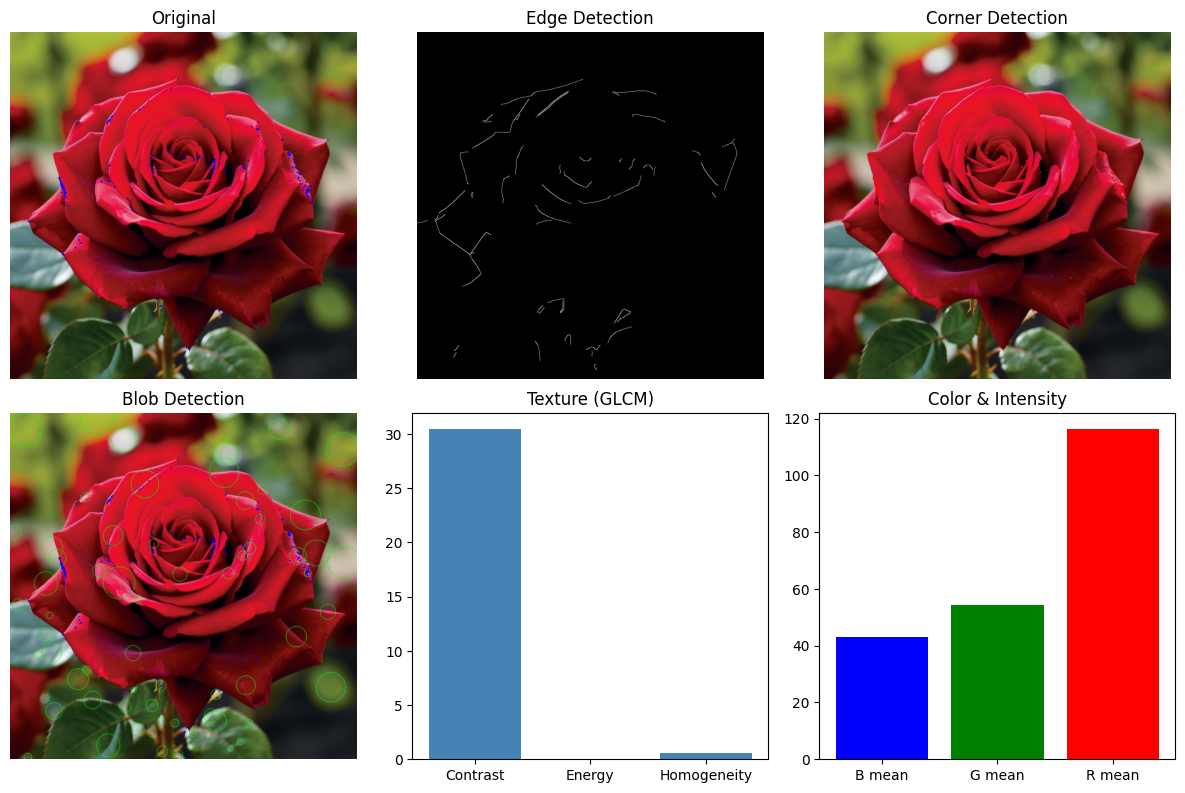

In [ ]:
blob_image   = cv2.drawKeypoints(image, keypoints, None, (0,255,0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
corner_image = image.copy()
corner_image[corners > 0.01 * corners.max()] = [0, 0, 255]

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1); plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));        plt.title('Original')
plt.subplot(2, 3, 2); plt.imshow(edges, cmap='gray');                             plt.title('Edge Detection')
plt.subplot(2, 3, 3); plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB)); plt.title('Corner Detection')
plt.subplot(2, 3, 4); plt.imshow(cv2.cvtColor(blob_image, cv2.COLOR_BGR2RGB));   plt.title('Blob Detection')
plt.subplot(2, 3, 5); plt.bar(['Contrast','Energy','Homogeneity'], [contrast, energy, homogeneity], color='steelblue'); plt.title('Texture (GLCM)')
plt.subplot(2, 3, 6); plt.bar(['B mean','G mean','R mean'], mean_val, color=['blue','green','red']); plt.title('Color & Intensity')

for ax in plt.gcf().axes[:4]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Original Rose: <br>
Interpretasi:
Objek utama berupa bunga mawar merah.Memiliki:warna dominan merah, tekstur kelopak, bentuk melingkar, tepi/edge yang cukup jelas.
<br><br>
Edge Detection:<br>
Interpretasi:
Garis putih menunjukkan batas objek atau perubahan intensitas tajam.Yang terdeteksi:tepi kelopak bunga, lekukan mawar, kontur daun. Background sebagian besar hitam karena tidak memiliki perubahan intensitas signifikan.

Corner Detection:<br>
Sistem mendeteksi titik-titik penting pada:ujung kelopak,lekukan bunga, pertemuan antar garis/edge.Titik sudut muncul pada area dengan perubahan intensitas besar dari berbagai arah.

Blob Detection:<br>
Lingkaran hijau menunjukkan area yang dianggap “blob”.Blob biasanya:area terang,area kontras, titik penting (keypoint).
sistem mendeteksi bagian tertentu pada bunga sebagai region penting<br><br>
Texture ( GLCM )<br>
sistem mendeteksi bagian tertentu pada bunga sebagai region penting.Nilai yang tinggi/rendah menunjukkan sifat tekstur gambar.<br>Contoh:<br>
Contrast tinggi → banyak perubahan tekstur.<br>
Homogeneity tinggi → tekstur lebih seragam.<br>
Energy tinggi → pola tekstur konsisten.<br>

Color& Intensity:<br>
Interpretasi:<br>
Merah (R) paling tinggi.
Hijau (G) sedang.
Biru (B) paling rendah.Artinya:citra sangat didominasi warna merah.

# Seleksi Fitur

In [ ]:
feature_names = [
    # Hu (7)
    'hu_0','hu_1','hu_2','hu_3','hu_4','hu_5','hu_6',
    # GLCM (3)
    'contrast','energy','homogeneity',
    # Color (6)
    'mean_b','mean_g','mean_r','std_b','std_g','std_r',
    # Edge (2)
    'edge_mean','edge_density',
    # Corner (2)
    'corner_mean','corner_max',
    # Blob (1)
    'blob_count',
]
feature_values = np.array([
    *hu_log,                                         # Hu (7)
    contrast, energy, homogeneity,                   # GLCM (3)
    *mean_val, *std_val,                             # Color (6)
    edges.mean(), (edges > 0).sum() / edges.size,    # Edge (2)
    corners.mean(), corners.max(),                   # Corner (2)
    len(keypoints),                                  # Blob (1)
])

feature_groups = {
    'Hu':     (list(range(7)),     'salmon'),
    'GLCM':   (list(range(7,10)),  'lightgreen'),
    'Color':  (list(range(10,16)), 'gold'),
    'Edge':   (list(range(16,18)), 'lightblue'),
    'Corner': (list(range(18,20)), 'plum'),
    'Blob':   ([20],               'wheat'),
}

feature_values_transformed = np.log1p(np.abs(feature_values)) * np.sign(feature_values)
features_normalized_v2     = np.zeros_like(feature_values_transformed)

for group_name, (indices, _) in feature_groups.items():
    group_vals = feature_values_transformed[indices]
    max_abs    = np.max(np.abs(group_vals))
    features_normalized_v2[indices] = group_vals / max_abs if max_abs > 0 else group_vals

mask         = np.isfinite(features_normalized_v2) & (np.abs(features_normalized_v2) > 0.05)
selected_idx = np.where(mask)[0]
selected_name = [feature_names[i] for i in selected_idx]
selected_val  = features_normalized_v2[selected_idx]

print(f"Fitur terpilih: {len(selected_idx)} dari {len(feature_names)}\n")
print(f"{'Index':<6} {'Nama':<22} {'Nilai Norm':>10}")
print("-" * 40)
for idx, name, val in zip(selected_idx, selected_name, selected_val):
    bar = "█" * int(abs(val) * 20)
    print(f"{idx:<6} {name:<22} {val:>8.4f}")

print(f"\nShape  : ({len(selected_val)},)")
print(f"Fitur  : {selected_name}")
print(f"Nilai  : {np.round(selected_val, 4)}")

Fitur terpilih: 19 dari 21

Index  Nama                   Nilai Norm
----------------------------------------
0      hu_0                     0.5358
1      hu_1                     0.9091
2      hu_2                     0.9696
3      hu_3                     0.9825
4      hu_4                     1.0000
5      hu_5                    -1.0000
6      hu_6                     1.0000
7      contrast                 1.0000
9      homogeneity              0.1325
10     mean_b                   0.7947
11     mean_g                   0.8426
12     mean_r                   1.0000
13     std_b                    0.7774
14     std_g                    0.8352
15     std_r                    0.8729
16     edge_mean                1.0000
18     corner_mean              0.5015
19     corner_max               1.0000
20     blob_count               1.0000

Shape  : (19,)
Fitur  : ['hu_0', 'hu_1', 'hu_2', 'hu_3', 'hu_4', 'hu_5', 'hu_6', 'contrast', 'homogeneity', 'mean_b', 'mean_g', 'mean_r', 'std_b', '

## Normalisasi Per-Kelompok

Alih-alih satu pembagi tunggal untuk semua fitur, setiap kelompok dinormalisasi **secara mandiri** menggunakan nilai maksimum kelompoknya sendiri.

---

### Mengapa Lebih Baik?

| Masalah (Normalisasi Global) | Solusi (Per-Kelompok) |
|---|---|
| Hu Moments "dihukum" karena nilainya kecil | Setiap kelompok bersaing dalam konteks sendiri |
| GLCM (0–1) tenggelam oleh Corner yang besar | GLCM dinilai relatif terhadap sesama GLCM |
| Fitur besar selalu menang | Semua kelompok punya kesempatan setara |

---

> Setiap fitur dinilai berdasarkan **seberapa informatif ia dalam kelompoknya**, bukan seberapa besar nilainya secara global.

Hasilnya, feature vector akhir merepresentasikan gambar secara **menyeluruh** dari berbagai sudut pandang — bentuk, tekstur, warna, tepi, sudut, dan blob.

# Kesimpulan

1. **Preprocessing yang dilakukan:**
- Resize
- Grayscale
- Normalisasi
- Noise Reduction
- Blurring/Smoothing

2. **Fitur yang dibuat:**<br>
| # | Kelompok | Fitur | Jumlah |
|---|----------|-------|--------|
| 1–7 | Hu Moments | hu_0, hu_1, hu_2, hu_3, hu_4, hu_5, hu_6 | 7 |
| 8–10 | Texture (GLCM) | contrast, energy, homogeneity | 3 |
| 11–16 | Color & Intensity | mean_b, mean_g, mean_r, std_b, std_g, std_r | 6 |
| 17–18 | Edge Detection | edge_mean, edge_density | 2 |
| 19–20 | Corner Detection | corner_mean, corner_max | 2 |
| 21 | Blob Detection | blob_count | 1 |
| | **Total** | | **21** |

3. **fitur yang dipilih**<br>
Ada 19 Fitur yang dipilih dari 21:<br>
Fitur  : ['hu_0', 'hu_1', 'hu_2', 'hu_3', 'hu_4', 'hu_5', 'hu_6', 'contrast', 'homogeneity', 'mean_b', 'mean_g', 'mean_r', 'std_b', 'std_g', 'std_r', 'edge_mean', 'corner_mean', 'corner_max', 'blob_count']

4. **insight utama**<br>
Pipeline feature extraction yang diterapkan berhasil mengubah informasi visual dari gambar tanaman menjadi representasi numerik yang komprehensif dan diskriminatif. Dengan mengkombinasikan fitur bentuk (Hu Moments), tekstur (GLCM), warna (Color Statistics), tepi (Edge), sudut (Corner), dan region (Blob), setiap jenis tanaman dapat direpresentasikan secara unik dalam ruang fitur. Proses seleksi fitur dengan normalisasi per-kelompok memastikan bahwa kontribusi setiap aspek visual terwakili secara seimbang, sehingga feature vector akhir yang dihasilkan memiliki potensi yang baik untuk membedakan kelima kelas tanaman — Rose, Anggrek, Jasmine, Cactus, dan Sunflower — dalam tahap klasifikasi selanjutnya.

5. **kendala selama pengerjaan.**<br>
Menurut saya, ini sangat menarik bagi saya, hal baru. yaitu Gambar. karna kebetulan saya ingin benar-benar ingin memahami proses dibalik mesin mempelajari gambar. maka dari itu, saya harus baca-baca artikel, website, mengenai preprocessing, rekayasa fitur, cara load data, dan lain sebagainya.
walaupun adanya AI, namun saya harus mengerti dulu apa yang membedakan Image preprocessing dengan text pre processing yang biasanya saya gunakan. <br><br>
Saya keliru pada Blob Detection dan corner detection, output awalnya itu tidak seperti yang diharapkan. dimana, pada corner detection, gambar tidak memperlihatkan titik-titik yang membentuk pola pada gambar. dan juga pada blob detection, seharusnya lingkaran hijau melingkari bagian-bagian pada Rose. namun mesin tersebut hanya melingkari latar belakang dari Rose, yaitu pemandangan yang blur. itu salah besar. jadi setelah saya baca-baca, itu bukan output yang diharapkan. jadi saya perbaiki.<br><br>
Saya benar-benar membutuhkan waktu, untuk memahami pipeline dari Gambar. karna biasanya saya membedahi text. namun ini adalah tantangan saya untuk belajar lebih giat.

# Penggunaan AI

- Claude
- Chatgpt

Digunakan untuk:
- Memahami Pipeline dari alur bagaimana Image diproses.
- Debugging Error.
- Saran Fitur-Fitur yang akan digunakan pada Extraction Fitur.
- Bantu Dokumentasi/merapikan cell Markdown, agar lebih gampang dibaca dengan bantuan tabel.